# Abacus small box: one-at-a-time LRG parameter variations

Generate a fiducial single-tracer LRG catalogue at **z = 0.5**, then change one scalar parameter at a time. We compare satellite and central velocity bias, concentration/environment/shear assembly bias (central and satellite coefficients separately), and satellite-count dispersion `nu`.

All clustering panels use **`HOD.plot_stats`**, with the fiducial mock passed as **data**. The lower panels show `model / fiducial - 1` for $w_p$, $\xi_0$, and $\xi_2$. These are fractional differences, without measurement-error or significance estimates. Ratios can become large when the fiducial quadrupole crosses zero; exactly zero reference bins are omitted by the plotter.

Dependencies are the standard HODDIES environment: NumPy, SciPy, Matplotlib, Numba, abacusutils, mpytools, Corrfunc/pycorr and cosmoprimo with CLASS. Run cells in order, with a Python kernel using that environment. The first run reads particle files and compiles Numba kernels; subsequent runs reuse the cached environment fields. The HOD values below are illustrative, rather than a fit to observed LRGs.

In [3]:
from HODDIES.sim_loader import AbacusSummitSim


In [8]:
from HODDIES.plot_utils import get_STATS, register_stat
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from HODDIES import HOD 
import torch 
from HODDIES.sim_loader import AbacusSummitSim
from HODDIES.sim_loader import setup_logging
setup_logging()

NTHREADS = 8
FIX_SEED = 42
N_VARIATIONS = 20  # np.linspace default: lower this for a quicker preview

default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
    'load_field_particles': True  # Whether to load field particles
    
}

test=AbacusSummitSim(**default_abacus_param, nthreads=NTHREADS)


PARAMETER_GRIDS = {
    "f_sigv": np.linspace(0.5, 1.5, N_VARIATIONS),
    "f_vcen": np.linspace(0.0, 0.5, N_VARIATIONS),
    "assembly_bias": np.linspace(-1.0, 1.0, N_VARIATIONS),
    "nu": np.linspace(0.7, 2.0, N_VARIATIONS),
}
LRG_FIDUCIAL = dict(
    HOD_model="SHOD", Ac=0.6, log_Mcent=12.8, sigma_M=0.4,
    satellites=True, sat_HOD_model="Nsat_pow_law",
    As=0.6, M_0=12.8, M_1=13.8, alpha=1.0,
    density=None, nu=1.0, link_sat_to_central=False, conformity_bias=False,
    vel_sat="rd_normal", f_sigv=1.0, f_vcen=0.0, vsmear=0.0,
    assembly_bias={"c": [0.0, 0.0], "shear": [0.0, 0.0], "env": [0.0, 0.0]},
)
HOD_model = HOD(base_catalog=test, use_assembly_bias=True, LRG=LRG_FIDUCIAL)

LRG_FIDUCIAL = deepcopy(HOD_model.args["LRG"])
HOD_model.args['clustering_settings']['xi_rppi']['edges_rppi'] = (np.geomspace(.1, 30, 25), np.linspace(-40, 40, 81))
HOD_model.args['clustering_settings']['xi_smu']['edges_smu'] = (np.geomspace(.1, 30, 25), np.linspace(-1, 1, 201))

cat_fid = HOD_model.make_mock_cat(fix_seed=FIX_SEED, verbose=True) 
rp, ds_data = HOD_model.get_wp(cat_fid)
s, (xi0_fid, xi2_fid) = HOD_model.get_xiells(cat_fid)

data = {'wp': (rp, ds_data)}

PLOT_STATS = []
for name in ("wp", "xi0", "xi2"):
    alias = f"{name}_fiducial_ratio"
    register_stat(alias, **{**vars(get_STATS()[name]), "residual": "ratio", "residual_ylim": None})
    PLOT_STATS.append(alias)
FIDUCIAL_DATA = {
    PLOT_STATS[0]: {"LRG": (rp, ds_data)},
    PLOT_STATS[1]: {"LRG": (s, xi0_fid)},
    PLOT_STATS[2]: {"LRG": (s, xi2_fid)},
}
run_summary = [{"parameter": "fiducial", "value": "—", "N": len(cat_fid),
                "f_sat": float(np.mean(cat_fid["Central"] == 0))}]


[000000.00]  10-07 14:53 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000000.00]  10-07 14:53 AbacusSummitSim              INFO     Load Compaso catalogue from /home/antoine/Bureau/Transfert/postdoc/Abacus_sims/small/AbacusSummit_small_c000_ph3000/halos/z0.500 with particles...
[000002.80]  10-07 14:53 AbacusSummitSim              INFO     Done took 00:00:02
[000002.80]  10-07 14:53 AbacusSummitSim              INFO     Compute required columns...
[000002.87]  10-07 14:53 AbacusSummitSim              INFO     Done took 00:00:00
[000002.87]  10-07 14:53 AbacusSummitSim              INFO     Load Abacus particles using 10.000% of the subsample A...
[000003.97]  10-07 14:53 AbacusSummitSim              INFO     [0/2] halo_rv_A_000.asdf: 5,958,945 / 59,589,449 particles retained
[000006.55]  10-07 14:53 AbacusSummitSim              INFO     [1/2] field_rv_A_000.asdf: 9,520,723 / 95,207,226 particles retained
[000006.97]  10-07 14:53 AbacusSummitSim              INFO

In [11]:

def scalar_parameters(params):
    flat = {key: value for key, value in params.items() if key != "assembly_bias"}
    for proxy, values in params["assembly_bias"].items():
        for index, value in enumerate(values):
            flat[f"assembly_bias.{proxy}.{index}"] = value
    return flat

def plot_variation(parameter, values, title, proxy=None, component=None):
    """Sweep one scalar; overlay wp, xi0 and xi2 with fiducial ratio residuals."""
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or len(values) < 2 or not np.all(np.isfinite(values)) or np.ptp(values) == 0:
        raise ValueError("Provide a finite one-dimensional grid with at least two distinct values.")
    cmap = plt.get_cmap("viridis", len(values))
    norm = plt.Normalize(vmin=values.min(), vmax=values.max())
    fig = HOD_model.plot_stats(
        cat_fid, stats=PLOT_STATS, tracers=["LRG"], data=FIDUCIAL_DATA,
        residuals=True, show=False, color="black", data_color="0.35",
        label="Fiducial", figsize=(14, 6), fontsize=10, lw=2.2, zorder=4,
    )
    try:
        for value in values:
            color = cmap(norm(value))
            params = deepcopy(LRG_FIDUCIAL)
            key = parameter
            if proxy is None:
                params[parameter] = float(value)
            else:
                params["assembly_bias"][proxy][component] = float(value)
                key = f"assembly_bias.{proxy}.{component}"
            original, varied = scalar_parameters(LRG_FIDUCIAL), scalar_parameters(params)
            changed = [k for k in original if original[k] != varied[k]]
            # The grid may include the fiducial value, where no scalar changes.
            assert changed == ([key] if original[key] != varied[key] else []), (
                f"Expected only {key} to change; got {changed}"
            )
            HOD_model.args["LRG"] = params
            mock = HOD_model.make_mock_cat(fix_seed=FIX_SEED, verbose=False) if changed else cat_fid
            HOD_model.plot_stats(
                mock, stats=PLOT_STATS, tracers=["LRG"], fig=fig,
                residuals=True, show=False, color=color,
                label="_nolegend_", fontsize=10, lw=0.9, alpha=0.75,
            )
            run_summary.append({"parameter": key, "value": value, "N": len(mock),
                                "f_sat": float(np.mean(mock["Central"] == 0))})
            del mock
    finally:
        HOD_model.args["LRG"] = deepcopy(LRG_FIDUCIAL)
    # A colorbar replaces a long legend with one entry for every curve.
    # plot_stats uses a GridSpec with explicit bounds; move every panel
    # together to reserve space while keeping main/residual axes aligned.
    panels = [ax for main, resid in fig._plot_stats_axes
              for ax in (*main, *resid) if ax is not None]
    left = min(ax.get_position().x0 for ax in panels)
    right = max(ax.get_position().x1 for ax in panels)
    shrink = (0.86 - left) / (right - left)
    for ax in panels:
        pos = ax.get_position()
        ax.set_position([left + (pos.x0 - left) * shrink,
                         pos.y0, pos.width * shrink, pos.height])
    colorbar_axis = fig.add_axes([0.91, 0.16, 0.015, 0.68])
    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array(values)
    fig.colorbar(mappable, cax=colorbar_axis, label=parameter)
    fig.suptitle(title, y=1.02)
    plt.show()
    return fig

## Fiducial LRG HOD and redshift-space statistics

The fiducial has `f_sigv=1`, `f_vcen=0`, no assembly bias, and Poisson satellites (`nu=1`). Each assembly-bias entry is `[central coefficient, satellite coefficient]`. All runs keep the same halo catalogue, cosmology, HOD parameters and seed; `density=None` prevents automatic number-density renormalization from changing the other parameters. Counts may nevertheless change for occupation variations. A shared seed reduces realization differences, but cannot remove them when occupation draws change.

The current central prescription is **$v_{c,j}=v_{h,j}+f_{\rm vcen}V_{\rm rms}$ for each Cartesian component** (a deterministic offset, rather than an additional Gaussian draw). Redshift-space clustering uses the z line of sight. $w_p$ integrates to $\pi_{\max}=40\,h^{-1}\mathrm{Mpc}$, so a velocity change can affect this finite projection too.

## Satellite velocity bias

Change the satellite velocity dispersion around the default `f_sigv=1`.

In [ ]:
fig = plot_variation('f_sigv', PARAMETER_GRIDS["f_sigv"], 'Satellite velocity bias')
plt.close(fig)

## Central velocity bias

Change the central velocity offset from the default `f_vcen=0`.

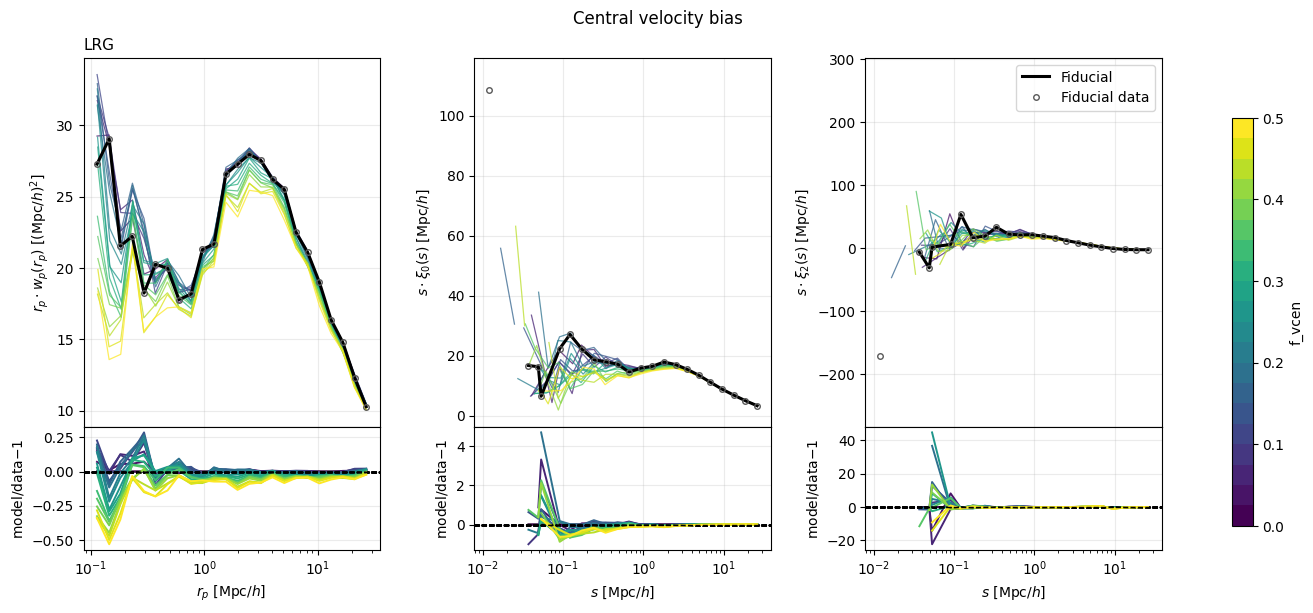

In [ ]:
fig = plot_variation('f_vcen', PARAMETER_GRIDS["f_vcen"], 'Central velocity bias')
plt.close(fig)

## Concentration: central assembly bias

Vary only the central coefficient of `assembly_bias["c"]`; its other coefficient and every other parameter remain fiducial.

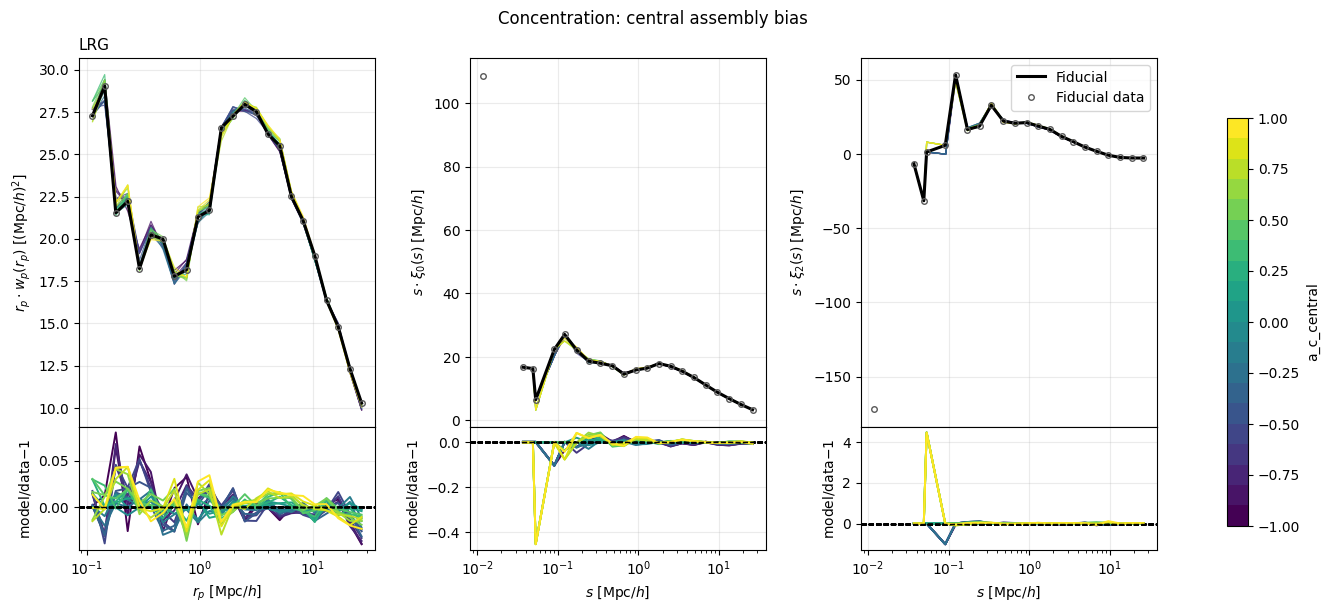

In [ ]:
fig = plot_variation('a_c_central', PARAMETER_GRIDS["assembly_bias"], 'Concentration: central assembly bias', proxy='c', component=0)
plt.close(fig)

## Concentration: satellite assembly bias

Vary only the satellite coefficient of `assembly_bias["c"]`; its other coefficient and every other parameter remain fiducial.

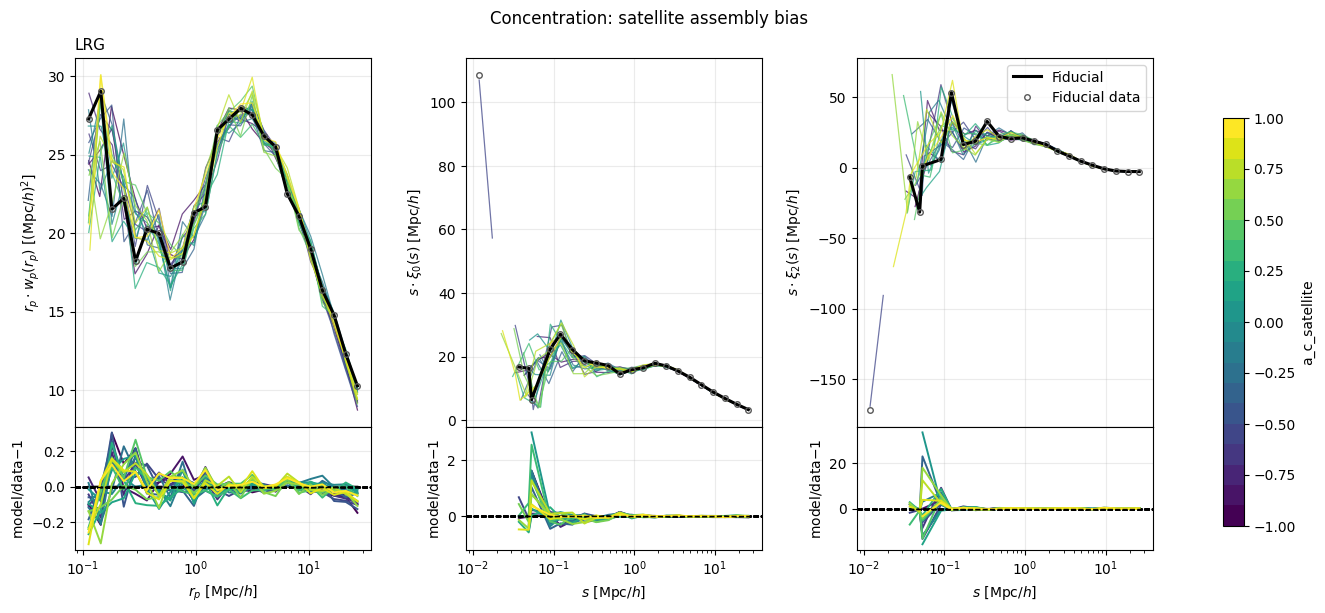

In [ ]:
fig = plot_variation('a_c_satellite', PARAMETER_GRIDS["assembly_bias"], 'Concentration: satellite assembly bias', proxy='c', component=1)
plt.close(fig)

## Shear: central assembly bias

Vary only the central coefficient of `assembly_bias["shear"]`; its other coefficient and every other parameter remain fiducial.

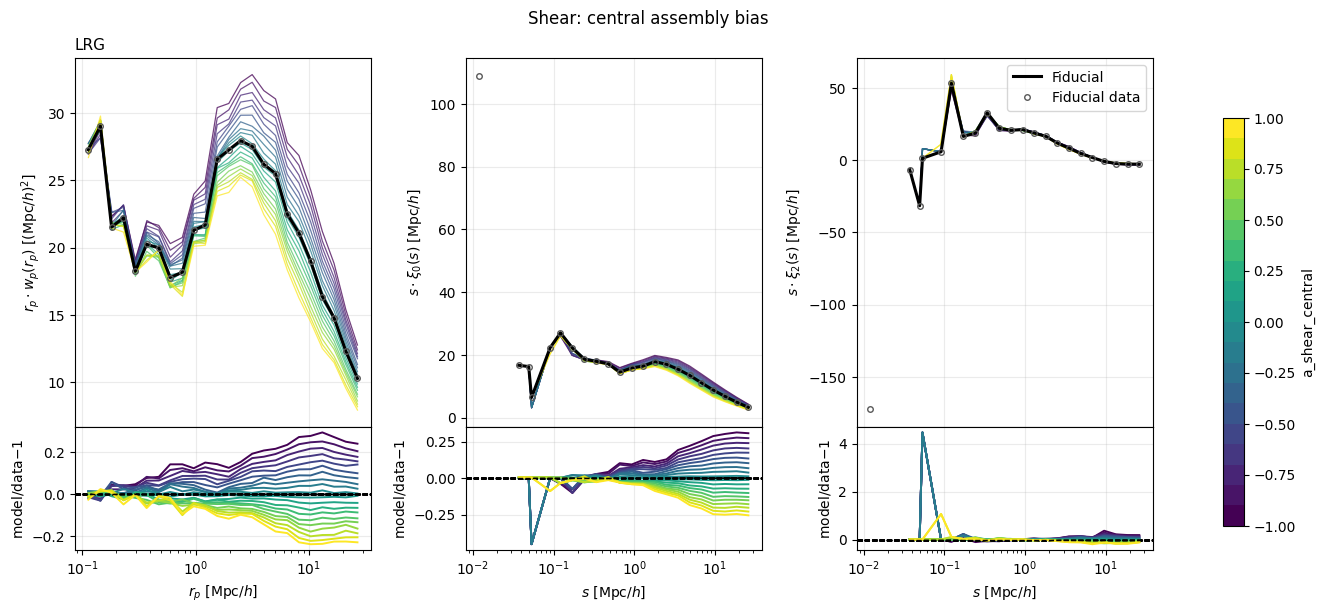

In [ ]:
fig = plot_variation('a_shear_central', PARAMETER_GRIDS["assembly_bias"], 'Shear: central assembly bias', proxy='shear', component=0)
plt.close(fig)

## Shear: satellite assembly bias

Vary only the satellite coefficient of `assembly_bias["shear"]`; its other coefficient and every other parameter remain fiducial.

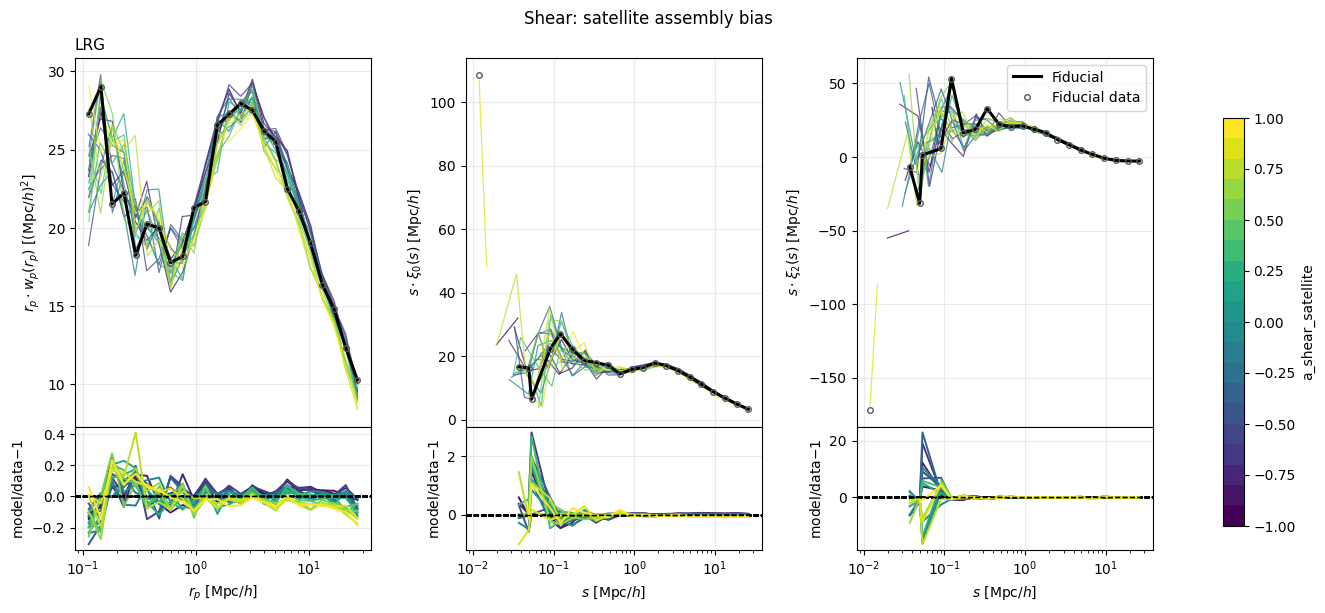

In [ ]:
fig = plot_variation('a_shear_satellite', PARAMETER_GRIDS["assembly_bias"], 'Shear: satellite assembly bias', proxy='shear', component=1)
plt.close(fig)

## Environment: central assembly bias

Vary only the central coefficient of `assembly_bias["env"]`; its other coefficient and every other parameter remain fiducial.

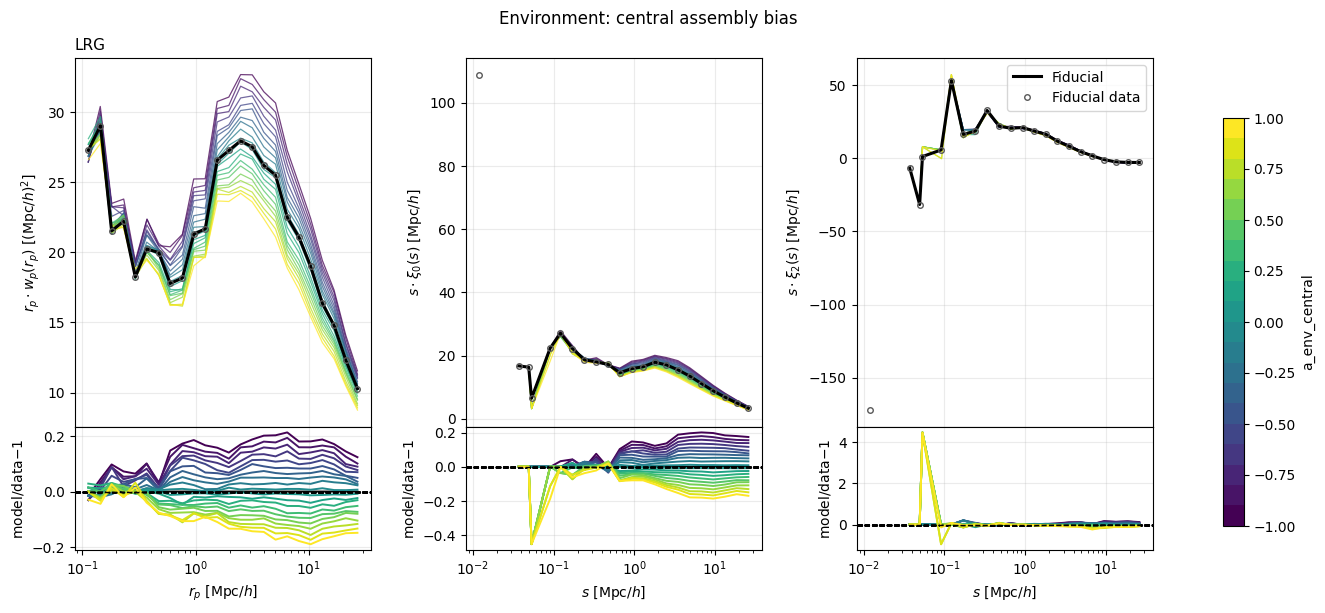

In [ ]:
fig = plot_variation('a_env_central', PARAMETER_GRIDS["assembly_bias"], 'Environment: central assembly bias', proxy='env', component=0)
plt.close(fig)

## Environment: satellite assembly bias

Vary only the satellite coefficient of `assembly_bias["env"]`; its other coefficient and every other parameter remain fiducial.

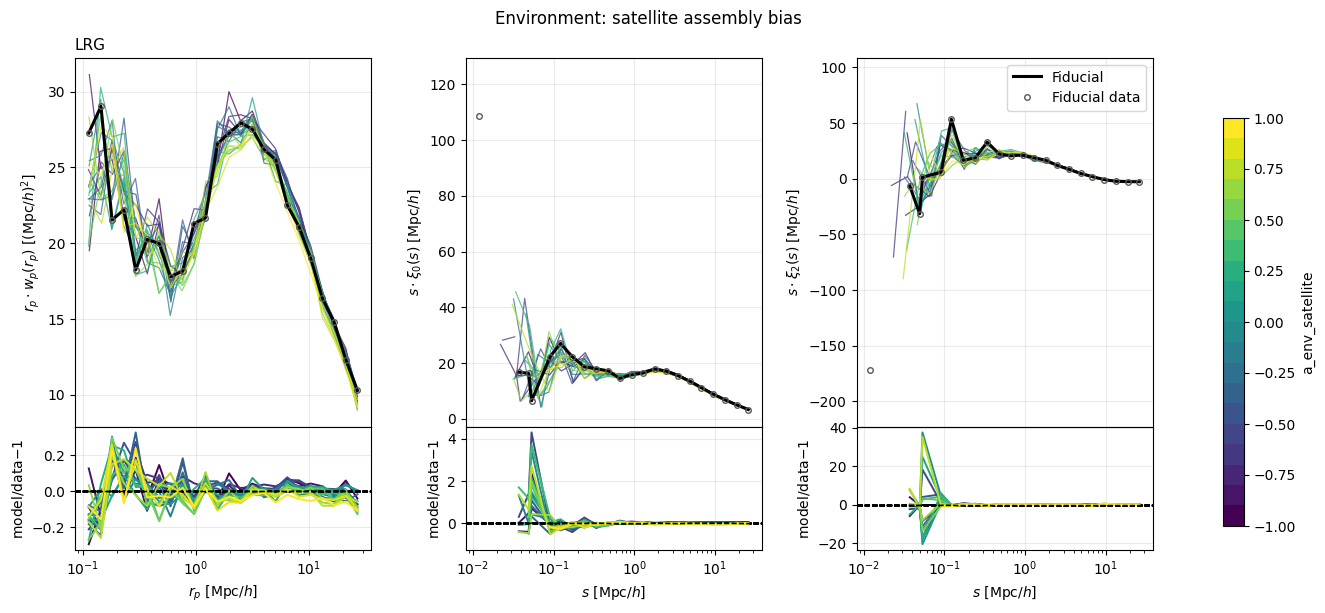

In [ ]:
fig = plot_variation('a_env_satellite', PARAMETER_GRIDS["assembly_bias"], 'Environment: satellite assembly bias', proxy='env', component=1)
plt.close(fig)

## Satellite-count dispersion

`nu=1` is Poisson. The Conway–Maxwell–Poisson sampler uses `nu<1` for overdispersion and `nu>1` for underdispersion, with a mean-matching approximation. Both conformity and central-satellite linking are disabled here.

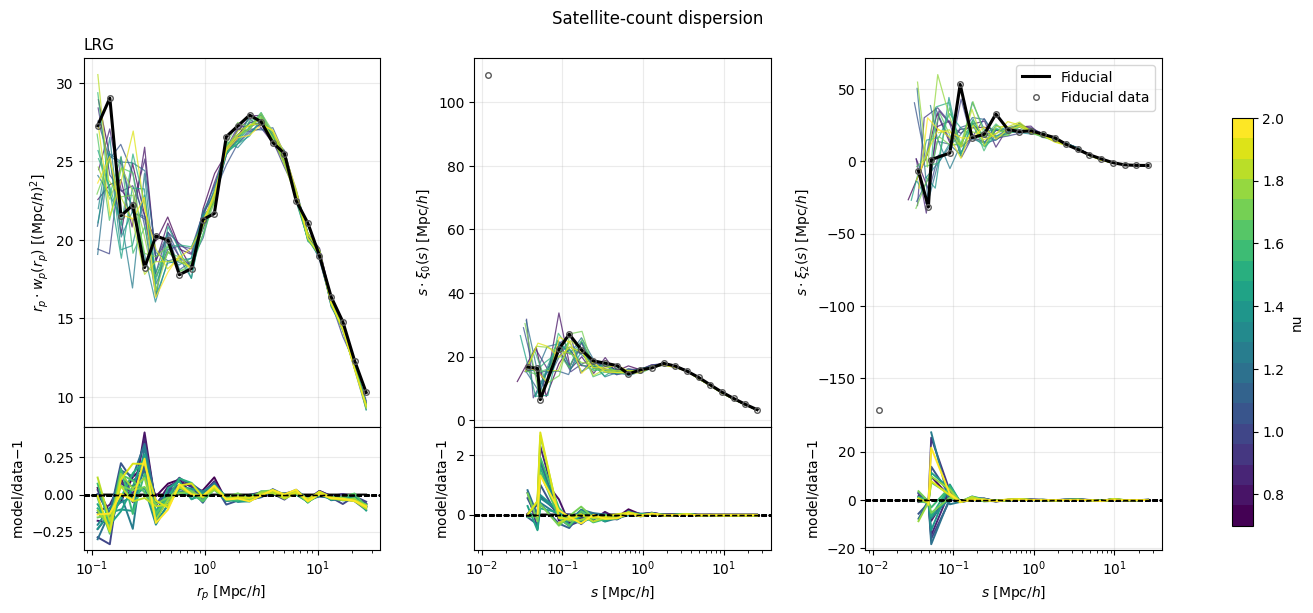

In [ ]:
fig = plot_variation('nu', PARAMETER_GRIDS["nu"], 'Satellite-count dispersion')
plt.close(fig)